### Analyze and process Shovels data for North Carolina permitting fact sheet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [3]:
#Use last 10 years of data only
START_YEAR = 2016
END_YEAR = 2025

## Load data

In [4]:
DATA_DIRECTORY = Path("../data")
DATA_FILE_PATH = "permitpower-nc.csv"

all_permits = pd.read_csv(DATA_DIRECTORY / DATA_FILE_PATH, escapechar="\\")
print(f"Total number of permit records: {len(all_permits):,} records")

Total number of permit records: 4,202,005 records


## Only completed permits

We want to filter out any permits that aren't final yet, because they won't have valid ending dates. 

In [5]:
status = all_permits['STATUS'].fillna('').str.strip()
final_permits = all_permits[status.isin(['final', ''])].copy()

print(f"After status filter: {len(final_permits):,} records")

After status filter: 3,355,489 records


## Process date variables and filter by start year

In [6]:
date_cols = ['FILE_DATE', 'ISSUE_DATE', 'FINAL_DATE']
for col in date_cols:
    if col in final_permits.columns:
        final_permits[col] = pd.to_datetime(final_permits[col], errors='coerce')

final_permits['starting_date'] = final_permits[['FILE_DATE', 'ISSUE_DATE']].min(axis=1)
final_permits['ending_date'] = final_permits[['FINAL_DATE', 'ISSUE_DATE']].max(axis=1)
final_permits['Year'] = final_permits['starting_date'].dt.year
final_permits.loc[final_permits['ending_date'].dt.year > END_YEAR, 'ending_date'] = pd.NaT

dated_permits = final_permits[final_permits['Year'].between(START_YEAR, END_YEAR)].copy()

print(f"After year filter: {len(dated_permits):,} records")

After year filter: 2,291,327 records


## Calculate date variables and remove invalid project lengths

In [7]:
dated_permits['Project_Time'] = (dated_permits['ending_date'] - dated_permits['starting_date']).dt.days
dated_permits['Approval_Time'] = (dated_permits['ISSUE_DATE'] - dated_permits['FILE_DATE']).dt.days

valid_permits = dated_permits[
    (dated_permits['Approval_Time'] >= 0) &
    (dated_permits['Project_Time'] >= 0)
].copy()

print(f"After removing invalid durations: {len(valid_permits):,} records")

After removing invalid durations: 1,787,912 records


## Residential, non new-construction

* Remove new construction
* Filter to only residential properties (or blank, which we treat as residential)

In [8]:
new_construction_filter = valid_permits[
    (valid_permits['NEW_CONSTRUCTION'] != 1) &
    ~valid_permits['SUBTYPE'].fillna('').str.contains('new construction', case=False) &
    ~valid_permits['TYPE'].fillna('').str.contains('new construction', case=False)
].copy()
print(f"After dropping new construction: {len(new_construction_filter):,} records")

residential_filter = new_construction_filter[
    new_construction_filter['PROPERTY_TYPE'].str.lower().isin(['residential']) |
    new_construction_filter['PROPERTY_TYPE'].isna() |
    (new_construction_filter['PROPERTY_TYPE'] == '')
].copy()
print(f"After filtering to residential: {len(residential_filter):,} records")

After dropping new construction: 1,665,232 records
After filtering to residential: 1,166,269 records


### Additional project type filtering to find non-residential 

Use regex pattern matching on PROPERTY_TYPE_DETAIL to flag projects that are tagged residential but actually include non-residential project type details. 

In [9]:
residential_pattern = (
    r'home|residence|triplex|townhouse|single family|condo|residential|'
    r'quadruplex|planned unit development|multi|module|mobile|house|duplex|'
    r'common|apartment|vacant land|timeshare|parcel with improvements|general|'
    r'dormitory|farm|crop land|agricultural|bed & breakfast'
)
commercial_pattern = r'office|store|warehouse'

detail = residential_filter['PROPERTY_TYPE_DETAIL']
detail_lower = detail.fillna('').str.lower()

is_null_or_empty = detail.isna() | (detail.str.strip() == '') | (detail == '\\N')

residential_flag = (
    detail_lower.str.contains(residential_pattern, regex=True) |
    is_null_or_empty
)
commercial_flag = detail_lower.str.contains(commercial_pattern, regex=True)

residential_filter_refined = residential_filter[residential_flag & ~commercial_flag].copy()

print(f"After refining residential filter:  {len(residential_filter_refined):,} records")

After refining residential filter:  1,160,986 records


In [10]:
wall_fence_pattern = r'wall|fence'
search_cols = ['DESCRIPTION', 'SUBTYPE', 'TYPE']

residential_filter_refined['WALL_FENCE'] = residential_filter_refined[search_cols].fillna('').apply(
    lambda col: col.str.contains(wall_fence_pattern, case=False, regex=True)
).any(axis=1)

# Combine HEAT_PUMP and HVAC into a single category
for col in ['HEAT_PUMP', 'HVAC']:
    residential_filter_refined[col] = residential_filter_refined[col].astype(str).str.upper() == 'TRUE'
residential_filter_refined['HVAC_HEAT_PUMP'] = (
    residential_filter_refined['HEAT_PUMP'] | residential_filter_refined['HVAC']
)

permit_type_cols = [
    'WALL_FENCE', 'WINDOW_DOOR', 'ROOFING', 'ELECTRICAL', 'ELECTRIC_METER',
    'HVAC_HEAT_PUMP', 'EV_CHARGER', 'SOLAR', 'BATTERY', 'WATER_HEATER', 'GAS', 'PLUMBING',
]

permit_cols = [c for c in permit_type_cols if c in residential_filter_refined.columns]

# Normalize to bool: handle actual booleans and string "TRUE"/"FALSE"
flags = residential_filter_refined[permit_cols].apply(
    lambda col: col.astype(str).str.upper() == 'TRUE'
)
single_trade_permits = residential_filter_refined[flags.any(axis=1)].copy()

print(f"After filtering to only single-trade permits:  {len(single_trade_permits):,} records")

After filtering to only single-trade permits:  758,235 records


---
## Analysis

### Approval time distribution (overview)

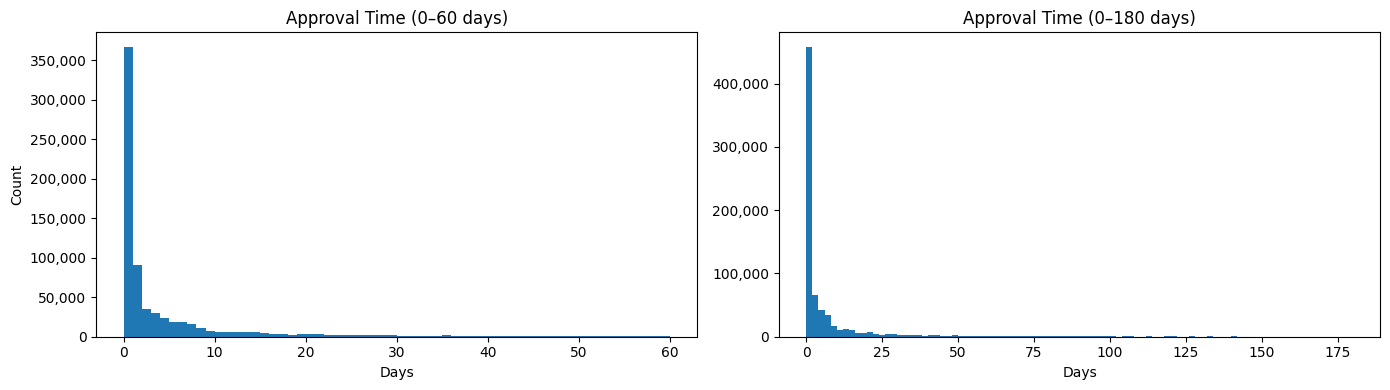

Median: 1 days
Mean:   17 days
p75:    6 days
p90:    28 days
p99:    336 days
% approved within 7 days:  79.2%
% approved within 30 days: 90.7%


In [11]:
approval = single_trade_permits['Approval_Time'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Zoomed to 0-60 days
axes[0].hist(approval[approval <= 60], bins=60, edgecolor='none')
axes[0].set_title('Approval Time (0–60 days)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Zoomed to 0-180 days
axes[1].hist(approval[approval <= 180], bins=90, edgecolor='none')
axes[1].set_title('Approval Time (0–180 days)')
axes[1].set_xlabel('Days')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"Median: {approval.median():.0f} days")
print(f"Mean:   {approval.mean():.0f} days")
print(f"p75:    {approval.quantile(0.75):.0f} days")
print(f"p90:    {approval.quantile(0.90):.0f} days")
print(f"p99:    {approval.quantile(0.99):.0f} days")
print(f"% approved within 7 days:  {(approval <= 7).mean():.1%}")
print(f"% approved within 30 days: {(approval <= 30).mean():.1%}")

95th percentile cutoff: 70 days  (37,893 records excluded, 5.0% of total)



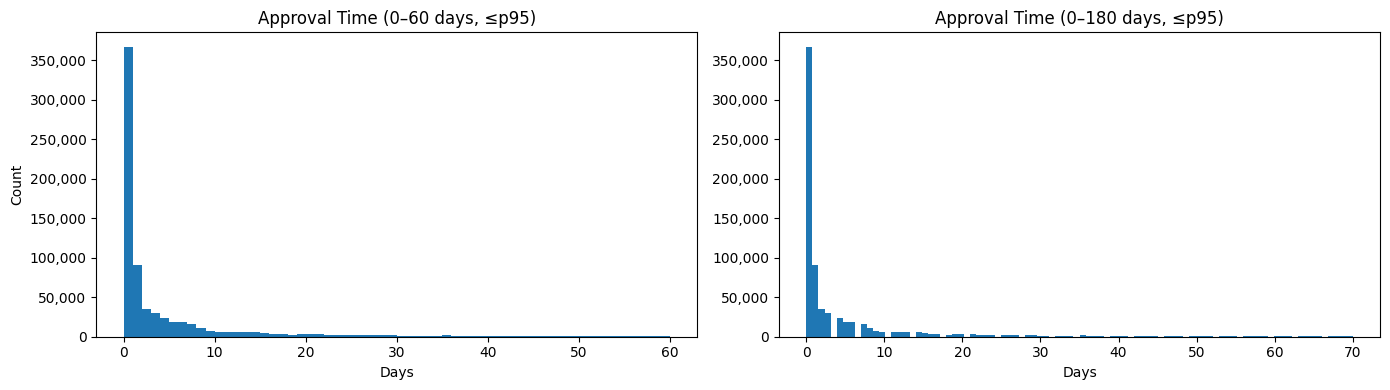

Median: 0 days
Mean:   5 days
p75:    4 days
p90:    15 days
% approved within 7 days:  83.3%
% approved within 30 days: 95.5%


In [12]:
# Same distributions capped at 95th percentile
approval = single_trade_permits['Approval_Time'].dropna()
p95 = approval.quantile(0.95)
approval_p95 = approval[approval <= p95]

print(f"95th percentile cutoff: {p95:.0f} days  ({(approval > p95).sum():,} records excluded, {(approval > p95).mean():.1%} of total)\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(approval_p95[approval_p95 <= 60], bins=60, edgecolor='none')
axes[0].set_title('Approval Time (0–60 days, ≤p95)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(approval_p95[approval_p95 <= 180], bins=90, edgecolor='none')
axes[1].set_title('Approval Time (0–180 days, ≤p95)')
axes[1].set_xlabel('Days')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print(f"Median: {approval_p95.median():.0f} days")
print(f"Mean:   {approval_p95.mean():.0f} days")
print(f"p75:    {approval_p95.quantile(0.75):.0f} days")
print(f"p90:    {approval_p95.quantile(0.90):.0f} days")
print(f"% approved within 7 days:  {(approval_p95 <= 7).mean():.1%}")
print(f"% approved within 30 days: {(approval_p95 <= 30).mean():.1%}")

### Stat 1: Average and median days to receive a permit

In [13]:
approval = single_trade_permits['Approval_Time'].dropna()

print(f"Average approval time: {approval.mean():.0f} days")
print(f"Median approval time:  {approval.median():.0f} days")
print(f"n: {len(approval):,}")

Average approval time: 17 days
Median approval time:  1 days
n: 758,235


### Stat 1a: Permit-level approval time quartiles (fastest vs. slowest 25%)

In [14]:
approval = single_trade_permits['Approval_Time'].dropna()

q25 = approval.quantile(0.25)
q75 = approval.quantile(0.75)

print(f"n: {len(approval):,}")
print(f"Fastest 25% (<= {q25:.0f} days): median = {approval[approval <= q25].median():.1f} days")
print(f"Slowest 25% (>= {q75:.0f} days): median = {approval[approval >= q75].median():.1f} days")

n: 758,235
Fastest 25% (<= 0 days): median = 0.0 days
Slowest 25% (>= 6 days): median = 19.0 days


### Stat 2: Approval time by jurisdiction quartile

In [15]:
# Median approval time per jurisdiction, excluding 0-day medians
juris_approval = (
    single_trade_permits.groupby('JURISDICTION')['Approval_Time']
    .median()
    .dropna()
)

q25 = juris_approval.quantile(0.25)
q75 = juris_approval.quantile(0.75)

print(f"Jurisdictions analyzed: {len(juris_approval):,}")
print(f"Fastest 25% of jurisdictions (median <= {q25:.0f} days): median = {juris_approval[juris_approval <= q25].median():.0f} days")
print(f"Slowest 25% of jurisdictions (median >= {q75:.0f} days): median = {juris_approval[juris_approval >= q75].median():.0f} days")

Jurisdictions analyzed: 57
Fastest 25% of jurisdictions (median <= 0 days): median = 0 days
Slowest 25% of jurisdictions (median >= 4 days): median = 8 days


### Stat 3: Permit cost by jurisdiction quartile (2022–2024)

In [16]:
# Filter to 2022-2024 and valid fees

single_trade_permits['FEES'] = pd.to_numeric(single_trade_permits['FEES'], errors='coerce')
fees = single_trade_permits[single_trade_permits['FEES'] > 0]

# Median fee per jurisdiction
juris_fees = fees.groupby('JURISDICTION')['FEES'].median().dropna()

q25 = juris_fees.quantile(0.25)
q75 = juris_fees.quantile(0.75)

print(f"Jurisdictions analyzed: {len(juris_fees):,}")
print(f"Overall median fee: ${juris_fees.median():,.0f}")
print(f"Cheapest 25% of jurisdictions (median <= ${q25:.0f}): median = ${juris_fees[juris_fees <= q25].median():,.0f}")
print(f"Most expensive 25% (median >= ${q75:.0f}): median = ${juris_fees[juris_fees >= q75].median():,.0f}")

Jurisdictions analyzed: 32
Overall median fee: $75
Cheapest 25% of jurisdictions (median <= $75): median = $75
Most expensive 25% (median >= $120): median = $150


### Stat 4: Correlation between approval time and project completion time (jurisdiction level)

In [17]:
from scipy import stats

# Aggregate to jurisdiction level medians + counts
juris_reg = single_trade_permits.groupby('JURISDICTION')[['Approval_Time', 'Project_Time']].agg(
    ['median', 'count']
)
juris_reg.columns = ['_'.join(c) for c in juris_reg.columns]
juris_reg = juris_reg.rename(columns={
    'Approval_Time_median': 'Approval_Time',
    'Project_Time_median': 'Project_Time',
    'Approval_Time_count': 'n_approval',
    'Project_Time_count': 'n_project',
})

MAX_MEDIAN_PROJECT_TIME = 300  # days — exclude jurisdictions with unusually long median project times

juris_reg = juris_reg.dropna(subset=['Approval_Time', 'Project_Time'])
juris_reg = juris_reg[
    (juris_reg['Approval_Time'] > 0) &
    (juris_reg['Project_Time'] > 0) &
    (juris_reg['Project_Time'] <= MAX_MEDIAN_PROJECT_TIME) &
    (juris_reg['n_approval'] >= 100) &
    (juris_reg['n_project'] >= 100)
]

slope, intercept, r, p, se = stats.linregress(juris_reg['Approval_Time'], juris_reg['Project_Time'])

print(f"Jurisdictions in regression: {len(juris_reg):,}")
print(f"Slope (project days per approval day): {slope:.2f}")
print(f"Intercept:                             {intercept:.1f}")
print(f"R²:                                    {r**2:.3f}")
print(f"p-value:                               {p:.2e}")
print()
display(juris_reg[['Approval_Time', 'Project_Time', 'n_approval', 'n_project']].sort_values('Approval_Time'))

Jurisdictions in regression: 24
Slope (project days per approval day): 10.05
Intercept:                             34.8
R²:                                    0.709
p-value:                               2.49e-07



,Approval_Time,Project_Time,n_approval,n_project
JURISDICTION,,,,
BURLINGTON,1.00,70.00,11814,11814
PERSON COUNTY,1.00,21.00,2613,2613
CATAWBA,1.00,62.00,13594,13594
NEW HANOVER COUNTY,1.00,72.00,78912,78912
DURHAM,1.00,35.00,55421,55421
DURHAM COUNTY,1.00,35.00,6693,6693
GASTON COUNTY,1.00,16.00,16996,16996
HAYWOOD,1.00,41.50,738,738
LEE COUNTY,1.00,99.00,10269,10269


### Stat 5: Approval time IQR by permit type

In [18]:
PERMIT_TYPE_LABELS = {
    'WALL_FENCE':     'Wall / Fence',
    'WINDOW_DOOR':    'Window / Door',
    'ROOFING':        'Roofing',
    'ELECTRICAL':     'Electrical',
    'ELECTRIC_METER': 'Electric Meter',
    'HVAC_HEAT_PUMP': 'HVAC / Heat Pump',
    'EV_CHARGER':     'EV Charger',
    'SOLAR':          'Solar',
    'BATTERY':        'Battery Storage',
    'WATER_HEATER':   'Water Heater',
    'GAS':            'Gas',
    'PLUMBING':       'Plumbing',
}

melted = single_trade_permits[permit_cols + ['Approval_Time', 'FEES']].melt(
    id_vars=['Approval_Time', 'FEES'],
    var_name='permit_type',
    value_name='flag'
)
melted = melted[melted['flag'].astype(str).str.upper() == 'TRUE']
melted['FEES'] = pd.to_numeric(melted['FEES'], errors='coerce')
fees_nonzero = melted['FEES'].replace(0, pd.NA)

result = (
    melted.groupby('permit_type')
    .agg(
        q25=('Approval_Time', lambda x: x.quantile(0.25)),
        median=('Approval_Time', 'median'),
        mean=('Approval_Time', 'mean'),
        q75=('Approval_Time', lambda x: x.quantile(0.75)),
        pct_same_day=('Approval_Time', lambda x: (x == 0).mean() * 100),
        count=('Approval_Time', 'count'),
        fees_median=('FEES', lambda x: x[x > 0].median()),
        fees_mean=('FEES', lambda x: x[x > 0].mean()),
    )
    .query('count > 20')
    .sort_values('median')
    .rename(index=PERMIT_TYPE_LABELS)
)
result.index.name = 'Permit Type'
result['q25']         = result['q25'].round(1)
result['median']      = result['median'].round(1)
result['mean']        = result['mean'].round(0).astype(int)
result['q75']         = result['q75'].round(1)
result['pct_same_day']= result['pct_same_day'].round(1)
result['fees_median'] = result['fees_median'].round(0)
result['fees_mean']   = result['fees_mean'].round(0)
result.columns = ['25th Pctl (days)', 'Median (days)', 'Mean (days)', '75th Pctl (days)',
                  '% Same Day', 'Count', 'Median Fee ($)', 'Mean Fee ($)']

with pd.option_context('display.max_rows', None):
    display(result)

,25th Pctl (days),Median (days),Mean (days),75th Pctl (days),% Same Day,Count,Median Fee ($),Mean Fee ($)
Permit Type,,,,,,,,
Electric Meter,0.00,0.00,6,3.00,50.70,13620,65.00,95.00
HVAC / Heat Pump,0.00,0.00,13,4.00,52.50,306267,75.00,101.00
Electrical,0.00,1.00,16,6.00,48.70,321672,75.00,122.00
EV Charger,0.00,1.00,5,3.00,49.10,14061,75.00,88.00
Gas,0.00,1.00,10,4.00,45.50,77891,65.00,110.00
Water Heater,0.00,1.00,10,5.00,35.30,30884,73.00,97.00
Battery Storage,0.00,2.00,7,7.00,33.60,4333,100.00,130.00
Plumbing,0.00,2.00,27,12.00,38.40,145021,77.00,170.00
Roofing,0.00,3.00,21,13.00,35.00,5063,125.00,251.00


In [19]:
# 2025 capped to H1 (Jan–Jun) to avoid partial-year bias
year_filtered = single_trade_permits[
    ~((single_trade_permits['Year'] == 2025) & (single_trade_permits['starting_date'].dt.month > 6))
]

display(
    year_filtered.groupby('Year')['Approval_Time']
    .agg(
        q25=lambda x: x.quantile(0.25),
        median='median',
        q75=lambda x: x.quantile(0.75),
        count='count'
    )
)

,q25,median,q75,count
Year,,,,
"2,016.00",0.00,0.00,2.00,40191
"2,017.00",0.00,0.00,6.00,39648
"2,018.00",0.00,0.00,6.00,42915
"2,019.00",0.00,0.00,6.00,53672
"2,020.00",0.00,1.00,6.00,53181
"2,021.00",0.00,1.00,8.00,110739
"2,022.00",0.00,1.00,7.00,113516
"2,023.00",0.00,1.00,7.00,102901
"2,024.00",0.00,1.00,5.00,100785


### Approval time by year (IQR and mean)

In [20]:
display(
    single_trade_permits.groupby('Year')['Approval_Time']
    .agg(mean='mean', count='count')
    .round(1)
)

,mean,count
Year,,
"2,016.00",27.20,40191
"2,017.00",31.50,39648
"2,018.00",29.40,42915
"2,019.00",33.70,53672
"2,020.00",32.00,53181
"2,021.00",19.60,110739
"2,022.00",13.80,113516
"2,023.00",10.50,102901
"2,024.00",7.10,100785


### Approval time by season

In [21]:
def get_season(month):
    if month in (12, 1, 2):
        return 'Winter'
    elif month in (3, 4, 5):
        return 'Spring'
    elif month in (6, 7, 8):
        return 'Summer'
    else:
        return 'Fall'

single_trade_permits['Season'] = single_trade_permits['starting_date'].dt.month.map(get_season)

season_order = ['Spring', 'Summer', 'Fall', 'Winter']
display(
    single_trade_permits.groupby('Season')['Approval_Time']
    .agg(
        q25=lambda x: x.quantile(0.25),
        median='median',
        mean='mean',
        q75=lambda x: x.quantile(0.75),
        count='count'
    )
    .round(1)
    .reindex(season_order)
)

,q25,median,mean,q75,count
Season,,,,,
Spring,0.00,1.00,17.40,6.00,203775
Summer,0.00,1.00,16.60,6.00,212674
Fall,0.00,1.00,16.80,5.00,177680
Winter,0.00,1.00,17.70,6.00,164106


### Approval time by jurisdiction (median, mean, 75th, 90th percentile)

In [22]:
with pd.option_context('display.max_rows', None):
    display(
        single_trade_permits.groupby('JURISDICTION')['Approval_Time']
        .agg(
            median='median',
            mean='mean',
            p75=lambda x: x.quantile(0.75),
            p90=lambda x: x.quantile(0.90),
            count='count'
        )
        .round(1)
        .sort_values('median')
    )

,median,mean,p75,p90,count
JURISDICTION,,,,,
ALEXANDER,0.00,3.90,2.00,9.00,487
PINEHURST,0.00,0.00,0.00,0.00,8145
MECKLENBURG COUNTY,0.00,0.00,0.00,0.00,27027
PITT COUNTY,0.00,5.00,1.00,5.70,1904
LINCOLN COUNTY,0.00,1.20,0.00,3.00,19527
ROCKINGHAM COUNTY,0.00,5.50,2.00,8.00,6282
ROWAN COUNTY,0.00,2.40,0.00,5.00,39267
JACKSON COUNTY,0.00,1.60,1.00,6.20,17
WAYNE COUNTY,0.00,2.90,0.00,4.00,8164


### Same-day approvals (overall and by jurisdiction)

In [23]:
approval = single_trade_permits['Approval_Time'].dropna()
same_day = (approval == 0).sum()
print(f"Same-day approvals: {same_day:,} / {len(approval):,} ({same_day / len(approval):.1%})")

Same-day approvals: 367,010 / 758,235 (48.4%)


In [24]:
with pd.option_context('display.max_rows', None):
    display(
        single_trade_permits.dropna(subset=['Approval_Time'])
        .groupby('JURISDICTION')['Approval_Time']
        .agg(
            same_day=lambda x: (x == 0).sum(),
            count='count'
        )
        .query('count >= 1000')
        .assign(pct_same_day=lambda df: (df['same_day'] / df['count'] * 100).round(1))
        .sort_values('pct_same_day', ascending=False)
    )

,same_day,count,pct_same_day
JURISDICTION,,,
ASHEVILLE,1002,1002,100.00
MECKLENBURG COUNTY,27027,27027,100.00
BUNCOMBEE COUNTY,31252,31252,100.00
HIGH POINT,22421,22421,100.00
PINEHURST,8094,8145,99.40
GOLDSBORO,9097,10584,86.00
CUMBERLAND COUNTY,15961,18717,85.30
GARNER,1089,1311,83.10
LINCOLN COUNTY,15498,19527,79.40


In [25]:
melted = single_trade_permits[permit_cols + ['Approval_Time', 'JURISDICTION']].melt(
    id_vars=['Approval_Time', 'JURISDICTION'],
    var_name='permit_type',
    value_name='flag'
)
melted = melted[melted['flag'].astype(str).str.upper() == 'TRUE']

juris_type_stats = (
    melted.groupby(['JURISDICTION', 'permit_type'])['Approval_Time']
    .agg(
        q25=lambda x: x.quantile(0.25),
        median='median',
        q75=lambda x: x.quantile(0.75),
        mean='mean',
        pct_same_day=lambda x: (x == 0).mean() * 100,
        count='count'
    )
    .round(1)
    .reset_index()
)

output_path = Path('../data/approval_time_by_jurisdiction_and_type.csv')
juris_type_stats.to_csv(output_path, index=False)
print(f"Written {len(juris_type_stats):,} rows to {output_path}")
display(juris_type_stats.head(20))

Written 499 rows to ../data/approval_time_by_jurisdiction_and_type.csv


,JURISDICTION,permit_type,q25,median,q75,mean,pct_same_day,count
0,ALEXANDER,BATTERY,29.00,29.00,29.00,29.00,0.00,1
1,ALEXANDER,ELECTRICAL,0.00,0.00,2.00,3.60,56.70,208
2,ALEXANDER,GAS,0.00,1.00,2.00,1.50,48.50,33
3,ALEXANDER,HVAC_HEAT_PUMP,0.00,0.00,2.00,5.00,60.70,206
4,ALEXANDER,PLUMBING,0.00,0.00,1.00,2.00,66.20,65
5,ALEXANDER,SOLAR,0.20,1.00,22.00,13.30,33.30,6
6,ALEXANDER,WALL_FENCE,1.00,10.00,11.00,7.40,20.00,5
7,APEX,ELECTRICAL,10.50,31.00,64.20,37.30,0.00,6
8,APEX,GAS,0.50,1.00,4.00,2.70,33.30,3
9,APEX,HVAC_HEAT_PUMP,1.00,2.00,3.00,11.80,22.20,9


### Export: Approval time stats by jurisdiction and permit type

In [26]:
all_raw = all_permits.copy()

# Parse dates
all_raw['FILE_DATE'] = pd.to_datetime(all_raw['FILE_DATE'], errors='coerce')
all_raw['ISSUE_DATE'] = pd.to_datetime(all_raw['ISSUE_DATE'], errors='coerce')
all_raw['FINAL_DATE'] = pd.to_datetime(all_raw['FINAL_DATE'], errors='coerce')

# Status filter
status = all_raw['STATUS'].fillna('').str.strip()
all_raw = all_raw[status.isin(['final', ''])]

# Residential filter
residential_mask = (
    all_raw['PROPERTY_TYPE'].str.lower().isin(['residential']) |
    all_raw['PROPERTY_TYPE'].isna() |
    (all_raw['PROPERTY_TYPE'] == '')
)

# Single-trade permit type filter
permit_cols_present = [c for c in permit_type_cols if c in all_raw.columns]
flags = all_raw[permit_cols_present].apply(lambda col: col.astype(str).str.upper() == 'TRUE')
has_permit_type = flags.any(axis=1)

all_filtered = all_raw[residential_mask & has_permit_type].copy()
print(f"Total after filters: {len(all_filtered):,}")

date_coverage = all_filtered.groupby('JURISDICTION').apply(
    lambda g: pd.Series({
        'count': len(g),
        'pct_missing_file_date':  g['FILE_DATE'].isna().mean() * 100,
        'pct_missing_issue_date': g['ISSUE_DATE'].isna().mean() * 100,
        'pct_missing_final_date': g['FINAL_DATE'].isna().mean() * 100,
    })
).round(1)

with pd.option_context('display.max_rows', None):
    display(date_coverage.sort_values('pct_missing_file_date'))

Total after filters: 920,508


/var/folders/n_/rbh3_bsn3h9cv6rx2h1bftm80000gn/T/ipykernel_85466/2098556370.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  date_coverage = all_filtered.groupby('JURISDICTION').apply(


,count,pct_missing_file_date,pct_missing_issue_date,pct_missing_final_date
JURISDICTION,,,,
ALEXANDER,390.00,0.00,11.30,0.00
HENDERSON,"87,656.00",0.00,9.30,20.70
HIGH POINT,"11,748.00",0.00,0.00,0.10
WAYNE COUNTY,"5,967.00",0.00,0.70,2.00
JACKSON COUNTY,16.00,0.00,0.00,6.20
JACKSONVILLE,"16,663.00",0.00,87.40,2.70
JOHNSTON COUNTY,1.00,0.00,0.00,0.00
LEE COUNTY,"8,315.00",0.00,2.30,0.10
MCDOWELL COUNTY,"1,475.00",0.00,5.20,0.00


In [27]:
# --- Jurisdiction size analysis: join NC household data ---

hh = pd.read_csv('../data/nc_city_households.csv', usecols=['Geographic Area Name', 'total_households', 'total_sf_households'])
hh.columns = ['city', 'total_households', 'sf_households']
hh['city_upper'] = hh['city'].str.upper()

# Filter permits to non-county jurisdictions
non_county = single_trade_permits[
    ~single_trade_permits['JURISDICTION'].str.contains('COUNTY', case=False, na=False)
].copy()

# Join on jurisdiction name (both uppercase)
merged = non_county.merge(hh[['city_upper', 'total_households', 'sf_households']],
                          left_on='JURISDICTION', right_on='city_upper', how='inner')

matched = merged['JURISDICTION'].nunique()
total   = non_county['JURISDICTION'].nunique()
print(f"Jurisdictions matched: {matched} / {total} ({matched/total:.0%})")
print(f"Permits matched: {len(merged):,} / {len(non_county):,} ({len(merged)/len(non_county):.0%})")

# Quartiles based on unique jurisdiction SF household counts (not permit rows)
juris_sf = merged.drop_duplicates('JURISDICTION')[['JURISDICTION', 'sf_households', 'total_households']].copy()
juris_sf['sf_quartile'] = pd.qcut(juris_sf['sf_households'], q=4,
                                   labels=['Q1 (smallest)', 'Q2', 'Q3', 'Q4 (largest)'])
merged = merged.merge(juris_sf[['JURISDICTION', 'sf_quartile']], on='JURISDICTION', how='left')

# Fees: numeric, zeros set to NaN so they're excluded from fee stats
merged['FEES_num'] = pd.to_numeric(merged['FEES'], errors='coerce')
merged.loc[merged['FEES_num'] == 0, 'FEES_num'] = float('nan')

result = merged.groupby('sf_quartile', observed=True).agg(
    jurisdiction_count=('JURISDICTION', 'nunique'),
    permit_count=('Approval_Time', 'count'),
    sf_hh_median=('sf_households', 'median'),
    approval_median=('Approval_Time', 'median'),
    approval_mean=('Approval_Time', 'mean'),
    pct_over_7d=('Approval_Time', lambda x: (x > 7).mean() * 100),
    fees_median=('FEES_num', 'median'),
    fees_mean=('FEES_num', 'mean'),
)

result['approval_median'] = result['approval_median'].round(1)
result['approval_mean']   = result['approval_mean'].round(1)
result['pct_over_7d']     = result['pct_over_7d'].round(1)
result['fees_median']     = result['fees_median'].round(0)
result['fees_mean']       = result['fees_mean'].round(0)
result['sf_hh_median']    = result['sf_hh_median'].round(0).astype(int)
result.index.name = 'SF Household Quartile'
result.columns = ['Jurisdictions', 'Permits', 'Median SF HHs',
                  'Median Approval (days)', 'Mean Approval (days)', '% > 7 Days',
                  'Median Fee ($)', 'Mean Fee ($)']

display(result)

Jurisdictions matched: 30 / 32 (94%)
Permits matched: 358,736 / 359,961 (100%)


,Jurisdictions,Permits,Median SF HHs,Median Approval (days),Mean Approval (days),% > 7 Days,Median Fee ($),Mean Fee ($)
SF Household Quartile,,,,,,,,
Q1 (smallest),8,94796,5006,7.00,71.70,48.20,100.00,141.00
Q2,7,37404,9299,0.00,8.90,12.40,66.00,95.00
Q3,7,45675,21640,0.00,10.70,18.00,110.00,142.00
Q4 (largest),8,180861,126995,1.00,12.50,26.40,65.00,99.00


In [28]:
# Which non-county jurisdictions didn't match?
unmatched = set(non_county['JURISDICTION'].dropna().unique()) - set(hh['city_upper'].unique())
unmatched_counts = (
    non_county[non_county['JURISDICTION'].isin(unmatched)]
    .groupby('JURISDICTION')
    .size()
    .sort_values(ascending=False)
    .rename('permit_count')
)
print(f"Unmatched jurisdictions: {len(unmatched_counts)}")
display(unmatched_counts)

Unmatched jurisdictions: 2


JURISDICTION
HAYWOOD      738
ALEXANDER    487
Name: permit_count, dtype: int64

In [ ]:
# --- Solar permit approval stats (2020–2024) ---

solar = single_trade_permits[
    (single_trade_permits['SOLAR'] == True) |
    (single_trade_permits['SOLAR'].astype(str).str.upper() == 'TRUE')
].copy()
solar = solar[solar['Year'].between(2020, 2024)]

def approval_stats(df, label):
    at = df['Approval_Time'].dropna()
    return {
        'Label':            label,
        'Total solar permits analyzed (2020-2024)':          len(at),
        '% Same-Day approval (0d)':  str(round((at == 0).mean() * 100)) + '%',
        '% approved within 1 Day':   str(round((at <= 1).mean() * 100)) + '%',
        '% approved within 7 Days':  str(round((at <= 7).mean() * 100)) + '%',
        'Median approval time (days)':    round(at.median()),
        'Mean (days)':      round(at.mean()),
    }

# State-level row
rows = [approval_stats(solar, 'All Jurisdictions')]

# Top 5 jurisdictions by solar permit count
top5 = (
    solar.groupby('JURISDICTION')
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
)
for juris in top5:
    rows.append(approval_stats(solar[solar['JURISDICTION'] == juris], juris.title()))

summary = pd.DataFrame(rows).set_index('Label')
summary.index.name = None
display(summary)

summary.to_csv('../data/solar_approval_stats.csv')
print("Exported to ../data/solar_approval_stats.csv")

,Permits,% Same-Day (0d),% Within 1 Day,% Within 7 Days,Median (days),Mean (days)
All Jurisdictions,20345,20.30,31.40,63.40,5.00,12.50
New Hanover County,3346,7.10,19.40,68.90,6.00,11.60
Raleigh,3052,32.90,36.50,66.70,5.00,8.20
Durham,2065,29.60,66.40,91.50,1.00,3.90
Wake County,2039,2.80,4.80,44.70,8.00,13.10
Rowan County,1098,51.30,59.30,81.60,0.00,4.40


In [36]:
import requests

# --- Search for a contractor by name ---
SHOVELS_API_KEY  = 'YOUR_API_KEY_HERE'
CONTRACTOR_SEARCH_URL = 'https://api.shovels.ai/v2/contractors/search'
HEADERS          = {'X-API-Key': SHOVELS_API_KEY}

INSTALLER_NAME = 'Top Tier Solar'  # <-- fill in

r = requests.get(
    CONTRACTOR_SEARCH_URL,
    headers=HEADERS,
    params={'name': INSTALLER_NAME},
)
r.raise_for_status()
data = r.json()
print(f"Results for '{INSTALLER_NAME}':")
results = pd.json_normalize(data.get('items', data) if isinstance(data, dict) else data)
display(results)

HTTPError: 403 Client Error: Forbidden for url: https://api.shovels.ai/v2/contractors/search?name=Top+Tier+Solar